Reduced-Order Overlapping Schwarz Waveform Relaxation for the Heat Equation
===========================================================================

This Jupyter notebook demonstrates the Reduced-Order Overlapping Schwarz Waveform Relaxation (ROSWR) method for solving the heat equation using the `ROSWRProblem` class. The goal is to show how to set up and solve a simple heat equation, visualize the results, and compare them with a reference solution obtained from FEM or an exact solution. A particular focus is placed on the convergence behavior of the ROSWR method. For this purpose, a user-defined `histconfig` is used to track the evolution of relevant quantities across iterations. In the convergence analysis section, a short tutorial on `HistoryConfig` is provided, explaining how to configure and monitor the history of metrics during the Schwarz iteration. This notebook serves as a practical guide for implementing and analyzing the ROSWR method in a 1D setting, providing insights into its performance and convergence properties. We will proceed in a step-by-step manner, starting with the problem setup, followed by the solution process, and concluding with the visualization and convergence analysis. Before introducing the ROSWR method, we will first solve the heat equation using a standard FEM approach to establish a reference solution for comparison and also introduce the OSWR method to provide a baseline for understanding the improvements offered by the ROSWR method.


We consider the heat equation on a domain $\Omega \subset \mathbb{R}^d$ over the time interval $(t_0, T)$:
$$
\begin{aligned}
\partial_t u - \Delta u &= f(x,t) \quad \text{in } \Omega \times (t_0, T), \\
u &= g(x,t) \quad \text{on } \partial \Omega \times (t_0, T), \\
u(x,t_0) &= u_0(x) \quad \text{in } \Omega.
\end{aligned}
$$
Here, $u$ denotes the temperature distribution, $f$ is a source term, $g$ is the prescribed boundary data, and $u_0$ is the initial condition at time $t_0$. In this notebook, we will consider only the cases where the spatial domain $\Omega$ is one- or two-dimensional, i.e., $d = 1$ or $d = 2$.

In [1]:
from utils.logger import configure_logging
configure_logging(level="info", stream = None)

### 1D Heat Problem

We consider the heat equation on the one-dimensional domain $\Omega \subset \mathbb{R}$:
$$
\begin{aligned}
\partial_t u - \partial_{xx} u &= f(x,t) \quad \text{in } \Omega \times (0,T), \\
u &= g(x,t) \quad \text{on } \partial \Omega \times (0,T), \\
u(x,0) &= u_0(x) \quad \text{in } \Omega.
\end{aligned}
$$
The boundary condition can also be written explicitly in the case $\Omega = (a,b)$ as
$$
u(a,t) = g_0(t), \quad u(b,t) = g_1(t), \quad t > 0.
$$
However, the first formulation is more general and will be used in the following discussion. We now consider the specific problem
$$
\begin{aligned}
\partial_t u - \partial_{xx} u &= 5e^{-(t-2)^2-(x-\frac{1}{4})^2} \quad \text{in } (0,1)\times(0,T), \\
u(0,t) &= 0, \quad u(1,t) = e^{-t} \quad t > 0, \\
u(x,0) &= x^2 \quad \text{in } (0,1),
\end{aligned}
$$
and solve it using the finite element method (FEM) to obtain a reference solution. The boundary data is given in the general form $u = g(x,t)$ on $\partial \Omega = \{0,1\}$, where
$$
g(x,t) =
\begin{cases}
0, & x = 0, \\
e^{-t}, & x = 1.
\end{cases}
$$

In [2]:
import numpy as np
from fem.mesh import Mesh

# Spatial domain definition (mesh generation)
vert1D = np.linspace(0, 1, 100)
mesh1D = Mesh(vertices = vert1D, dim = 1)

# Time domain definition (ntime = (T - t0)/dt + 1 for uniform time steps)
t0, T, ntime = 0.0, 3.0, 301
time_grid = np.linspace(t0, T, ntime)


In [3]:
# Print mesh information using rich console
from rich.console import Console
from rich.panel import Panel
console = Console()
console.print(Panel(mesh1D.info(), title = "[bold yellow]Mesh Information[/bold yellow]", border_style="cyan", expand = False))

╭───────── Mesh Information ──────────╮
│ Dimension: 1D                       │
│ Domain: 0                           │
│ Nodes: 100                          │
│ Elements (lines): 99                │
│ Boundary nodes: 2                   │
│ Boundary elements: 2                │
│ Measure (length): 1.0               │
│ Mesh size (h): 0.010101010101010166 │
╰─────────────────────────────────────╯

In [4]:
from fem.femspace import FEMSpace

# Linear Lagrange finite element space
femspace1D = FEMSpace(mesh = mesh1D, domain = 'interval', degree = 1)

In [5]:
# Define the source term, initial condition, and boundary condition
def source_term(x, t):
    return 5 * np.exp(-(t - 2)**2 - (x - 0.25)**2)

def initial_condition(x):
    return x**2

boundary_condition = np.vstack([np.zeros(ntime), np.exp(-time_grid)])

All the necessary components to define the heat problem are now available, so we can create an instance of the `HeatProblem` class. This class encapsulates the problem data and provides a convenient interface for solving the problem using `OSWR` and `ROSWR` methods. The `HeatProblem` class takes as input the spatial mesh, the time interval, the source term, the boundary condition, and the initial condition.

In [6]:
from fom.heat_fom import HeatProblem

# Define 1D Heat problem
problem1D = HeatProblem(femspace = femspace1D, t0 = t0, T = T, f = source_term, g = boundary_condition, h = initial_condition)

Now it is time to make some choices regarding the numerical methods to be used for solving the problem. The first choice is how to handle the nonhomogeneous boundary conditions. There are three **lifting** options provided in the `HeatProblem` class for handling nonhomogeneous boundary conditions: `'nodal'`, `'harmonic'`, and `'parabolic'`. In this notebook, we will use the `'nodal'` option, which constructs a lifting function that satisfies the boundary conditions at the nodes of the mesh. This approach is straightforward and works well for our problem. The other options can be explored in future experiments to see how they affect the solution and convergence of the OSWR method. The next choice to make is the **time-stepping scheme** for the reference solution. We will use the backward Euler method, which is implicit and unconditionally stable, making it a good choice for parabolic problems like the heat equation. The last but not least choice is the **linear solver** for the reference solution. We will use a direct solver, which is efficient for small to medium-sized problems and provides an exact solution (up to machine precision). For larger problems, iterative solvers can be considered by changing `solver` parameter in the `solve` method of the `HeatProblem` class.

In [7]:
from fem.linearsolver import DirectSolver

# Solve the 1D Heat problem using nodal lifting and theta method with theta = 1 (backward Euler)
heat_solution1D = problem1D.solve(time_grid = time_grid, lift = 'nodal', theta = 1, solver = DirectSolver())

Heat Solver: ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░ | 0/300 [00:00<?, ?step/s] , t=0.000e+00/home/abdanar/thesis/fem/linearsolver.py:202: SparseEfficiencyWarning: splu converted its input to CSC format
  self._lu = sc.sparse.linalg.splu(A)
Heat Solver: ███████████████████████████████████ | 300/300 [00:01<00:00, 241.04step/s] , t=2.990e+00


The `SolutionVisualizer` class in the `visualization.visualize` module provides an interactive way to explore the solution of the heat problem. If `use_femspace=False`, the solution is displayed at the mesh vertices. If `use_femspace=True`, the solution is evaluated at user-defined spatial points `eval_points` using the finite element expansion. In this case, the solution is reconstructed as a linear combination of the finite element basis functions and evaluated at the specified points in space. A time slider is provided to display the solution at different time steps.


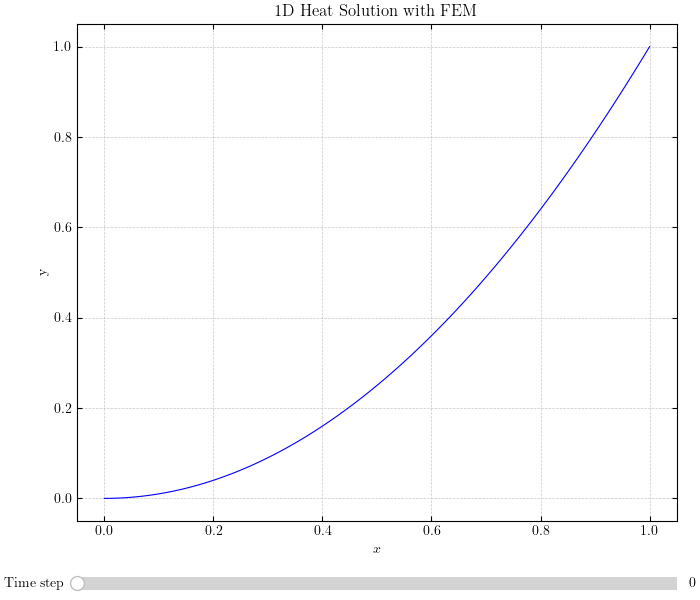

In [8]:
# Visualize the solution at the mesh vertices
%matplotlib widget
from visualization.visualize import SolutionVisualizer
visualizer = SolutionVisualizer(mesh = femspace1D.mesh, u = heat_solution1D, dt = time_grid[1] - time_grid[0], femspace = femspace1D)
visualizer.plot(linewidth = 0.8, linestyle = '-', color = 'blue', title = "1D Heat Solution with FEM")

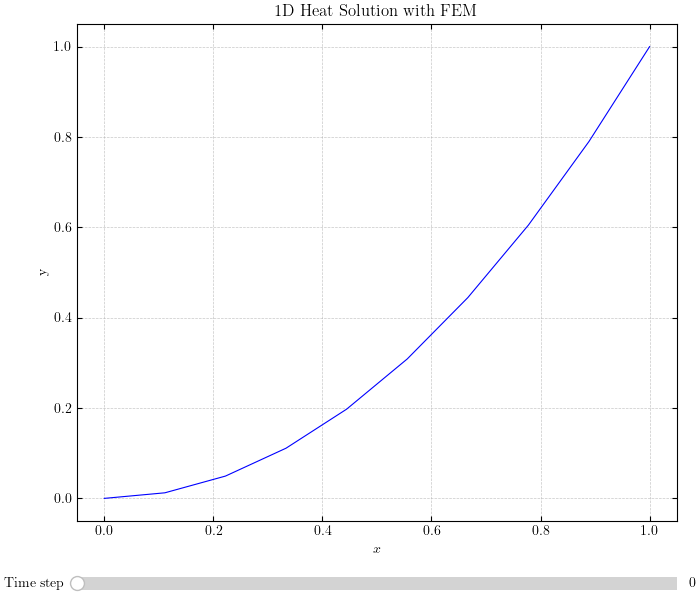

In [9]:
# Visualize the solution using the finite element expansion at user-defined evaluation points
points = np.linspace(0, 1, 10)
visualizer = SolutionVisualizer(mesh = femspace1D.mesh, u = heat_solution1D, dt = time_grid[1] - time_grid[0], femspace = femspace1D)
visualizer.plot(use_femspace = True, eval_points = points, linewidth = 0.8, linestyle = '-', color = 'blue', title = '1D Heat Solution with FEM')

### Overlapping Schwarz Waveform Relaxation (OSWR) method

Let us now introduce the Overlapping Schwarz Waveform Relaxation (OSWR) method for solving the heat equation. The OSWR method is an iterative domain decomposition method that decomposes the spatial domain into overlapping subdomains and iteratively solves the problem on each subdomain while exchanging information at the interfaces. For each subdomain at iteration $k$, the the following problem is solved over the entire time interval, which is why it is called a "waveform" relaxation method.
$$
\begin{aligned}
\partial_t u_i^{k} - \Delta u_i^{k} &= f(x,t) \quad \text{in } \Omega_i \times (t_0, T], \\
u_i^{k} &= g(x,t) \quad \text{on } \Gamma_{i0} \times (t_0, T], \\
u_i^{k} &= u_j^{k-1} \quad \text{on } \Gamma_{ij} \times (t_0, T], \\
u_i^{k}(x,t_0) &= u_0(x) \quad \text{in } \Omega_i,
\end{aligned}
$$
where $\Omega_i$ is the $i$-th subdomain, $\Gamma_{ij}$ is the interface boundary of a subdomain $\Omega_i$ that is shared with a neighboring subdomain $\Omega_j$, and $u_j^{k-1}$ is the solution from the previous iteration on the neighboring subdomain $\Omega_j$. In the case of overlapping decomposition, $\Gamma_{ij}$ may be defined differently, as it can be seen in the literature. There are two common approaches to defining the interface boundary between subdomains in overlapping decompositions: Let $\{\widetilde{\Omega}_i\}_{i=1}^N$ be a non-overlapping decomposition of a bounded domain $\Omega \subset \mathbb{R}^d$ and $\{\Omega_i\}_{i=1}^N$ be an overlapping decomposition of $\Omega$ obtained by extending the non-overlapping subdomains $\widetilde{\Omega}_i$, then for $i \neq j$, the interface boundary $\Gamma_{ij}$ can be defined in two ways:

1. $\Gamma_{ij} := \Gamma_{i}^{\text{int}} \cap \overline{\Omega}_j$  
2. $\Gamma_{ij} := \Gamma_{i}^{\text{int}} \cap \overline{\widetilde{\Omega}}_j$
   
Making note of this distinction is important, as it affects the analysis and implementation of domain decomposition methods. The first definition considers the interface boundary as the portion of $\Gamma_i^{\text{int}}$ that intersects with the extended subdomain $\Omega_j$, while the second definition restricts the interface boundary to the portion that intersects with the original non-overlapping subdomain $\widetilde{\Omega}_j$. In the `OSWRProblem` class, both definitions are implemented and can be selected using the `version` parameter. In this notebook, we will use the second definition, which is used the main paper on OSWR for the heat equation by Gander and Zhao (2002).

**Note:** For 1D case, these definitions are equivalent, as the interface boundary is just a point. However, for 2D and higher dimensions, these definitions can lead to different interface boundaries, which can affect the convergence behavior of the OSWR method. It is important to be aware of this distinction when implementing and analyzing domain decomposition methods.


In [10]:
from fom.oswr_heat import OSWRProblem

# Define Schwarz problem with 2 subdomains and overlap of 1 layer of elements with version 2 of the interface boundary decomposition
oswrproblem1D = OSWRProblem(heat_problem = problem1D, n = 2, overlap = 1, version = 2)

10:20:52 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Decomposing mesh into 2 subdomains with overlap of 1 layers using version 2 ...
10:20:52 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Mesh decomposition completed. Number of subdomains: 2


Once the OSWR problem is set up, we can solve it. The `OSWRProblem` class provides a `solve` method that takes the following parameters:

- `time_grid`: The time grid for the simulation, which is a 1D array of time points.
- `theta`: The theta value for the time-stepping scheme used in the subdomain solves. The default value is `theta=1.0`, which corresponds to the backward Euler method. Other values of `theta` can be used to implement different time-stepping schemes, such as Crank-Nicolson (`theta=0.5`) or forward Euler (`theta=0.0`).
- `lift`: The type of lifting function used to handle nonhomogeneous boundary conditions in the subdomain solves. The options are `'nodal'`, `'harmonic'`, and `'parabolic'`. The default is `'nodal'`.
- `method`: The type of Schwarz method to use, either 'AS' for Additive Schwarz or 'RAS' for Restricted Additive Schwarz. The default is 'RAS'.
- `solver`: The linear solver to use for the subdomain solves. The default is a direct solver, but iterative solvers can also be used for larger problems.
- `maxiter`: The maximum number of Schwarz iterations to perform. The default is 100.
- `tol`: The convergence tolerance for the Schwarz iterations. The default is 1e-9.
- `criterion`: The convergence criterion function that takes the old and new subdomain solutions and returns a scalar error value. The default is `max_difference`, which computes the maximum difference between the old and new solutions across all subdomains and time steps. Input values are dictionaries with keys as subdomain IDs and values as arrays of shape `(nnodes, ntime)` representing the local solution for each subdomain at all time steps.
- `histconfig`: An optional `HistoryConfig` object that specifies which quantities to track during the Schwarz iterations and how to compute them. If provided, the `solve` method will return a tuple containing the history of the tracked quantities and the final solution. If not provided, only the final solution will be returned.
  
The `solve` method will return either the final solution or a tuple containing the history of the tracked quantities and the final solution, depending on whether `histconfig` is provided. The history can be used to analyze the convergence behavior of the OSWR method by plotting the tracked quantities against the iteration number. Let us first consider the case where `histconfig` is not provided, and we only obtain the final solution.

In [ ]:
# Solve the problem using the Schwarz method with RAS, nodal lifting and theta method with theta = 1 (backward Euler)
oswr_solution1D = oswrproblem1D.solve(time_grid = time_grid, theta = 1, lift = 'nodal', method = 'RAS', maxiter = 50, tol = 1e-6)

In [ ]:
# Visualize the solution at the mesh vertices
visualizer_oswr = SolutionVisualizer(mesh = femspace1D.mesh, u = oswr_solution1D, dt = time_grid[1] - time_grid[0], femspace = femspace1D)
visualizer_oswr.plot(linewidth = 0.8, linestyle = '-', color = 'blue', title = "1D Heat Solution with OSWR")

It is better to plot the error of the OSWR solution with respect to the FEM solution, as the exact solution is not available. We can compute the error at the mesh vertices and visualize it using the `SolutionVisualizer` class. The error is computed as the absolute difference between the FEM solution and the OSWR solution at each vertex and time step. To avoid issues with logarithmic scaling when plotting the error, a small value (e.g., `1e-14`) is added to the error to ensure that it is strictly positive. The `SolutionVisualizer` class can then be used to create an interactive plot of the error, allowing us to explore how the error evolves over time and across the spatial domain. The following plots correspond to the error defined as 
$$
e(x, t) = |u_{\text{FEM}}(x, t) - u_{\text{OSWR}}(x, t)| + 1e^{-14},
$$
where $u_{\text{FEM}}$ is the solution obtained from the finite element method and $u_{\text{OSWR}}$ is the solution obtained from the OSWR method. By visualizing this error, we can gain insights into the accuracy of the OSWR method and identify regions in space where the error is larger, which may indicate areas where the OSWR method struggles to capture the solution accurately, such as overlapping regions. As we discussed above, you can plot the error at user-defined evaluation points using the finite element expansion by setting `use_femspace=True` and providing the desired evaluation points in the `eval_points` parameter.

In [ ]:
# Visualize the error between the FEM and OSWR solutions at the mesh vertices
error1D_oswr = np.abs(heat_solution1D - oswr_solution1D) + 1e-14 # add small value to avoid log(0) issues
visualizer_error = SolutionVisualizer(mesh = femspace1D.mesh, u = error1D_oswr, dt = time_grid[1] - time_grid[0], femspace = femspace1D)
visualizer_error.plot(figsize = (6, 3), dpi = 150, logscale = True, ylabel = 'e', ymin = 1e-14, ymax = 1e-0, linewidth = 0.8, linestyle = '-', color = 'red', title = "Error between FEM and OSWR Solutions")

In [ ]:
# Visualize the solution using the finite element expansion at user-defined evaluation points
points = np.linspace(0, 1, 300)
visualizer_error.plot(use_femspace = True, eval_points = points, figsize = (6, 3), dpi = 150, logscale = True, ylabel = 'e', ymin = 1e-14, ymax = 1e-0, linewidth = 0.8, linestyle = '-', color = 'red', title = "Error between FEM and OSWR Solutions")

Now, we will analyze the convergence behavior of the OSWR method by tracking the history using a `HistoryConfig` object. This object allows us to specify which quantities we want to track during the Schwarz iterations and how to compute them. Let us first consider how to define `MetricSpec` objects to specify the metrics we want to track. The `MetricSpec` class allows us to specify the type of metric to compute, the spatial mode (whether to compute it on the entire domain or on specified subdomains), and the temporal mode (whether to compute it at specific time steps or as a combined space-time metric). You can use the following metric types to track the convergence behavior of the OSWR method:
- `ABSOLUTE_ERROR` which computes the absolute error between the current iterate and a reference solution (e.g., obtained from a direct solver or an exact solution) as
$$
e^{k}_{\text{abs}} = \|u - u^k\|,
$$
- `RELATIVE_ERROR` which computes the relative error between the current iterate and a reference solution as
$$
e^{k}_{\text{rel}} = \frac{\|u - u^k\|}{\|u\|},
$$,
- `CONVERGENCE_RATE` which computes the convergence rate between consecutive iterates as
$$
e^{k}_{\text{conv}} = \frac{\|u - u^k\|}{\|u - u^{k-1}\|},
$$,
- `ITERATION_ERROR` which computes the error between consecutive iterates as
$$
e^{k}_{\text{iter}} = \|u^k - u^{k-1}\|.
$$
The following norms are available for computing these metrics:
- `L2` norm, which computes 
$$
\|u(\cdot,t)\|_{L^2(\Omega)} = \left( \int_{\Omega} |u(x,t)|^2 \, dx \right)^{1/2}.
$$
at fixed time $t$, or the combined space-time norm
$$
\|u\|_{L^2(0,T;L^2(\Omega))} 
= \left( \int_{0}^{T} \int_{\Omega} |u(x,t)|^2 \, dx \, dt \right)^{1/2}.
$$
- `Linf` norm, which computes
$$
\|u(\cdot,t)\|_{L^\infty(\Omega)} = \sup_{x \in \Omega} |u(x,t)|.
$$
at fixed time $t$, or the combined space-time norm
$$
\|u\|_{L^\infty(0,T;L^\infty(\Omega))} = \sup_{x \in \Omega, t \in (0,T)} |u(x,t)|.
$$
- `H1_seminorm`, which computes
$$
|u(\cdot,t)|_{H^1(\Omega)} = \left( \int_{\Omega} |\nabla u(x,t)|^2 \, dx \right)^{1/2}.
$$
at fixed time $t$, or the combined space-time norm
$$
|u|_{L^2(0,T;H^1(\Omega))} = \left( \int_{0}^{T} \int_{\Omega} |\nabla u(x,t)|^2 \, dx \, dt \right)^{1/2}.
$$
- `H1` norm, which computes
$$
\|u(\cdot,t)\|_{H^1(\Omega)} = \left( \int_{\Omega} |u(x,t)|^2 + |\nabla u(x,t)|^2 \, dx \right)^{1/2}.
$$
at fixed time $t$, or the combined space-time norm
$$
\|u\|_{L^2(0,T;H^1(\Omega))} = \left( \int_{0}^{T} \int_{\Omega} |u(x,t)|^2 + |\nabla u(x,t)|^2 \, dx \, dt \right)^{1/2}.
$$
You can control this behavior using the `MetricSpec` class by setting the `temporal` parameter to `TemporalMode.STATIC` for fixed time metrics or `TemporalMode.TIME` for combined space-time metrics. For example, if you want to track the relative error in the $L^2(0,T;L^2(\Omega))$ norm, you can create a `MetricSpec` object as follows:
```python
metric_spec = MetricSpec(name = MetricType.RELATIVE_ERROR, spatial = SpatialMode.GLOBAL, temporal = TemporalMode.STATIC)
```
The above are general norms that can be used to compute the error metrics at each iteration on the domain \(\Omega\). However, we can also compute these metrics on specified subdomains (by their IDs) instead of the entire domain. The `solve` method of the `OSWRProblem` class will compute the specified metrics at each iteration and return the history of these metrics. Note that if the metric is desired to be computed on the entire domain, `solve` method combine the local solutions from all subdomains to compute the global solution at each iteration, which can then be compared to the reference solution to compute the error metrics. To compute whether the metric is computed on the entire domain or on specified subdomains, we have `SpatialMode` options in the `MetricSpec` class, which can be set to `GLOBAL`, `SUBDOMAINS`, or `BOTH`. If `GLOBAL` is selected, the metric will be computed on the entire domain by combining the local solutions from all subdomains, if `SUBDOMAINS` is selected, the metric will be computed separately on each specified subdomain, and if `BOTH` is selected, the metric will be computed both globally and on the specified subdomains. For example, if you want to track the relative error in the $L^2(0,T;L^2(\Omega))$ norm, you can create a `MetricSpec` object as follows:
```python
metric_spec = MetricSpec(name = MetricType.RELATIVE_ERROR, spatial = SpatialMode.GLOBAL, temporal = TemporalMode.STATIC)
```
or if you want to compute both the global absolute error and the absolute error on subdomains with IDs 1 and 2 at time steps 25, 50, and 75, you can create a `MetricSpec` object as follows:
```python
metric_spec = MetricSpec(name = MetricType.ABSOLUTE_ERROR, spatial = SpatialMode.BOTH, temporal = TemporalMode.TIME)
```
To specify which subdomains to compute the metrics on, you can create a `HistoryConfig` object and set the `subdomains` parameter to a list of the desired subdomain IDs, and which norm to use, you can set the `norm` parameter. For example, for the second case above, you can create a `HistoryConfig` object as follows:
```python
histconfig = HistoryConfig(metric_specs = [metric_spec], uh = heat_solution1D, norm = NormType.L2, time_indices = [25, 50, 75], subdomains = [1, 2], mode = 'fem')
```
where `time` is the list of time step indices at which to compute the metrics, and `subdomains` is the list of subdomain IDs on which to compute the metrics. The `norm` parameter specifies which norm to use for computing the metrics, and it can be set to `L2`, `Linf`, `H1_seminorm`, or `H1`. By configuring the `HistoryConfig` object with the desired metrics, norms, time steps, and subdomains, you can track the convergence behavior of the OSWR method in a detailed manner and gain insights into how the solution evolves across iterations and how it compares to the reference solution. But, you should specify the reference solution to compute the error metrics, which can be done by providing the `exact` parameter for the exact solution or the `uh` parameter for the FEM solution. If both `exact` and `uh` are provided, the `mode` parameter can be used to specify whether to use the exact solution or the FEM solution for computing the error metrics, which can be set to `fem` or `exact`. For example, the last example given above uses the FEM solution as the reference solution for computing the absolute error metrics on subdomains 1 and 2 at time steps 25, 50, and 75 using the L2 norm. You can provide list of `MetricSpec` objects to the `metric_specs` parameter of the `HistoryConfig` object to track multiple metrics simultaneously. For example, if you want to track both the global absolute error on the entire domain and the convergence rate on subdomains 1 and 2 at time steps 25, 50, and 75 using the L2 norm, you can create a `HistoryConfig` object as follows:
```python
metric_spec1 = MetricSpec(name = MetricType.ABSOLUTE_ERROR, spatial = SpatialMode.GLOBAL, temporal = TemporalMode.STATIC)
metric_spec2 = MetricSpec(name = MetricType.CONVERGENCE_RATE, spatial = SpatialMode.SUBDOMAINS, temporal = TemporalMode.TIME)
histconfig = HistoryConfig(metric_specs = [metric_spec1, metric_spec2], uh = heat_solution1D, norm = NormType.L2, time_indices = [25, 50, 75], subdomains = [1, 2], mode = 'fem')
```
After configuring the `HistoryConfig` object, you can pass it to the `solve` method of the `OSWRProblem` class, which will compute the specified metrics at each iteration and return the history of these metrics along with the final solution. Let us now discuss the output `History` object returned by the `solve` method when a `HistoryConfig` is provided. The useful information in the `History` object is stored in the `values` attribute, which is a dictionary where the keys are the names of the tracked metrics and the values are dictionary where the keys are either `global` or `subdomains` depending on the `spatial` mode specified in the `MetricSpec`, and the values are numpy arrays for ``global`` metrics or dictionaries of numpy arrays for `subdomains` metrics where the keys are the subdomain IDs. The shape of the numpy arrays depends on the `temporal` mode specified in the `MetricSpec`. If `temporal` is set to `STATIC`, the shape of the array will be `(niter,)`, where `niter` is the number of Schwarz iterations performed. If `temporal` is set to `TIME`, the shape of the array will be `(niter, ntime)`, where `ntime` is the length of `time_indices` provided.

In [14]:
from utils.errornorms import NormType
from utils.history import HistoryConfig, MetricSpec, MetricType, SpatialMode, TemporalMode

# Define a history configuration
subdomains = [1, 2]
time_indices = np.array([25, 50, 75])
metrics = [MetricSpec(MetricType.ABSOLUTE_ERROR, SpatialMode.GLOBAL, TemporalMode.STATIC),
           MetricSpec(MetricType.CONVERGENCE_RATE, SpatialMode.SUBDOMAINS, TemporalMode.TIME)]
config = HistoryConfig(metrics = metrics, norm = NormType.L2, uh = heat_solution1D, time_indices = time_indices, subdomains = subdomains, mode = 'fem')


In [ ]:
# Solve the problem using the Schwarz method with RAS, nodal lifting and theta method with theta = 1 (backward Euler)
history1D, oswr_solution1D = oswrproblem1D.solve(time_grid = time_grid, theta = 1, lift = 'nodal', method = 'RAS', maxiter = 100, tol = 1e-6, histconfig = config)

Now let us visualize the convergence history of the OSWR method by plotting the tracked metrics against the iteration number using `history1D.values`.

In [ ]:
# Solution visualization
global_history = history1D.values[MetricType.ABSOLUTE_ERROR]["global"] # shape (niter,)
subdomain_history = history1D.values[MetricType.CONVERGENCE_RATE]["subdomains"] # shape dictionary of shape {domainID: shape (niter, ntime)}
visualizer1D = SolutionVisualizer(mesh = femspace1D.mesh, u = oswr_solution1D, dt = time_grid[1] - time_grid[0], femspace = femspace1D)
styles = {1: {'color': 'orange', 'linestyle': '-', 'linewidth': 0.8},
          2: {'color': 'blue', 'linestyle': '-', 'linewidth': 0.8}}
visualizer1D.plot_iteration(data = global_history, figsize = (6, 3), dpi = 150, ylabel = rf"$\| u_{{FEM}} - u_{{OSWR}} \|_{{L^2(0,{T};L^2({vert1D[0]}, {vert1D[-1]}))}}$", color = 'black', linestyle = '-', linewidth = 0.8)
for i in range(len(time_indices)):
    visualizer1D.plot_iteration(data = {str(domainID): subdomain_history[domainID][:, i] for domainID in subdomain_history}, figsize = (6, 3), dpi = 150, title = r"Convergence Rate", xlabel = r"Iteration ($k$)", styles = styles,
                                ylabel = rf"$\dfrac{{\| u_{{FEM}}(t_{{{time_indices[i]}}}) - u^{{k}}_{{OSWR}}(t_{{{time_indices[i]}}}) \|_{{L^2({vert1D[0]}, {vert1D[-1]})}}}}{{\| u_{{FEM}}(t_{{{time_indices[i]}}}) - u^{{k-1}}_{{OSWR}}(t_{{{time_indices[i]}}}) \|_{{L^2({vert1D[0]}, {vert1D[-1]})}}}}$")

In 2002 paper of Gander and Zhao, for one dimensional heat equation with two subdomains $\Omega_1 = [0,\beta]$ and $\Omega_2 = [\alpha, 1]$, they showed that OSWR iteration converges superlinearly on bounded time intervals $t\in[0, T]$ with at least the rate

$$
\max_{j=1, 2}\sup_{x\in \Omega_{j}, t\in(0, T)}|u(x,t) - u_j^k(x, t)| \leq \text{erfc} \left( \dfrac{k(\beta - \alpha)}{2\sqrt{T}} \right)\max_{j=1, 2}\sup_{x\in \Omega_{j}, t\in(0, T)}|u(x,t) - u_j^0(x, t)|.
$$

As an example they take $(\alpha, \beta) \in \{(0.45, 0.55), (0.4, 0.6)\}$ and $T = 3$. These parameters can be used to set up the OSWR problem and track the convergence history to see how the error evolves across iterations and how it compares to the theoretical convergence rate given by the above inequality. To be more specific, 

- `n=2` and `overlap = 5` corresponds to the case $(\alpha, \beta) = (0.45, 0.55)$, and
- `n=2` and `overlap = 10` corresponds to the case $(\alpha, \beta) = (0.4, 0.6)$

considering the spatial domain $\Omega = (0,1)$ discretized with 100 vertices.

In [12]:
# Define Schwarz problems with 2 subdomains and different overlaps (5 and 10 layers of elements)
oswrproblem1D_5 = OSWRProblem(heat_problem = problem1D, n = 2, overlap = 5, version = 2)
oswrproblem1D_10 = OSWRProblem(heat_problem = problem1D, n = 2, overlap = 10, version = 2)

10:22:42 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Decomposing mesh into 2 subdomains with overlap of 5 layers using version 2 ...
10:22:42 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Mesh decomposition completed. Number of subdomains: 2
10:22:42 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Decomposing mesh into 2 subdomains with overlap of 10 layers using version 2 ...
10:22:42 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Mesh decomposition completed. Number of subdomains: 2


In [15]:
# Define a history configuration
subdomains = [1, 2]
metric_abs = [MetricSpec(MetricType.ABSOLUTE_ERROR, SpatialMode.SUBDOMAINS, TemporalMode.STATIC)]
config1D_2002 = HistoryConfig(metrics = metric_abs, norm = NormType.LINF, uh = heat_solution1D, subdomains = subdomains, mode = 'fem')

In [16]:
# Solve the problems using the Schwarz method with RAS, nodal lifting and theta method with theta = 1 (backward Euler)
history1D_5, oswr_solution1D_5 = oswrproblem1D_5.solve(time_grid = time_grid, theta = 1, lift = 'nodal', method = 'RAS', maxiter = 150, tol = 1e-14, histconfig = config1D_2002)
history1D_10, oswr_solution1D_10 = oswrproblem1D_10.solve(time_grid = time_grid, theta = 1, lift = 'nodal', method = 'RAS', maxiter = 150, tol = 1e-14, histconfig = config1D_2002)

10:23:09 | INFO | fom.oswr_heat | ================================================================================
10:23:09 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Starting solver
10:23:09 | INFO | fom.oswr_heat | dim: 1D | subdomains: 2 | method: RAS | theta: 1 | lift: nodal | version: 2 | maxiter: 150 | tol: 1.00e-14
10:23:09 | INFO | fom.oswr_heat | ================================================================================
Heat Solver: ███████████████████████████████████ | 300/300 [00:01<00:00, 291.48step/s] , t=2.990e+00
Heat Solver: ███████████████████████████████████ | 300/300 [00:01<00:00, 275.17step/s] , t=2.990e+00
10:23:17 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Iteration 1: error = 9.726923e-01
10:23:17 | INFO | fom.oswr_heat | [Schwarz Waveform Relaxation] Computing error metrics for iteration 1 ...
Heat Solver: ███████████████████████████████████ | 300/300 [00:02<00:00, 120.57step/s] , t=2.990e+00
Heat Solver: ███████████████████████████

In [17]:
from scipy.special import erfc
from utils.errornorms import ErrorNorms

def initial_error(problem, heat_solution, time_grid, config):
    sub_errors = {}
    initial = problem.initial_data(ntime = len(time_grid))
    for subdomain_id, subdomain in problem.subdomains.items():
        subfem = FEMSpace(mesh = subdomain, domain = femspace1D.domain, space = femspace1D.space, degree = femspace1D.degree)
        sub_est = ErrorNorms(femspace = subfem, u1 = initial[subdomain_id], u2 = heat_solution[problem.ltog[subdomain_id], :], time = time_grid, mode = 'fem')
        sub_error = sub_est.compute(config.norm) # scalar
        sub_errors[subdomain_id] = sub_error
    return np.max(np.stack(list(sub_errors.values())), axis=0)

# Extract necessary data for visualization
subdomain_history_5 = history1D_5.values[MetricType.ABSOLUTE_ERROR]["subdomains"] # shape dictionary of shape {domainID: shape (niter_5,)}
subdomain_history_10 = history1D_10.values[MetricType.ABSOLUTE_ERROR]["subdomains"] # shape dictionary of shape {domainID: shape (niter_10,)}

# Compute the maximum error across subdomains for each iteration, which corresponds to the left-hand side of the above inequality
lhs_bound_5 = np.max(np.stack(list(subdomain_history_5.values())), axis=0) # shape (niter_5,)
lhs_bound_10 = np.max(np.stack(list(subdomain_history_10.values())), axis=0) # shape (niter_10,)

# Compute the initial error term in the theoretical bound.
initial_error_5 = initial_error(oswrproblem1D_5, heat_solution1D, time_grid, config1D_2002)
initial_error_10 = initial_error(oswrproblem1D_10, heat_solution1D, time_grid, config1D_2002)

# Compute the theoretical upper bound
rhs_bound_5 = erfc(0.1*np.arange(len(lhs_bound_5)) / (2*np.sqrt(T)))*initial_error_5  # shape (niter_5,)
rhs_bound_10 = erfc(0.2*np.arange(len(lhs_bound_10)) / (2*np.sqrt(T)))*initial_error_10  # shape (niter_10,)

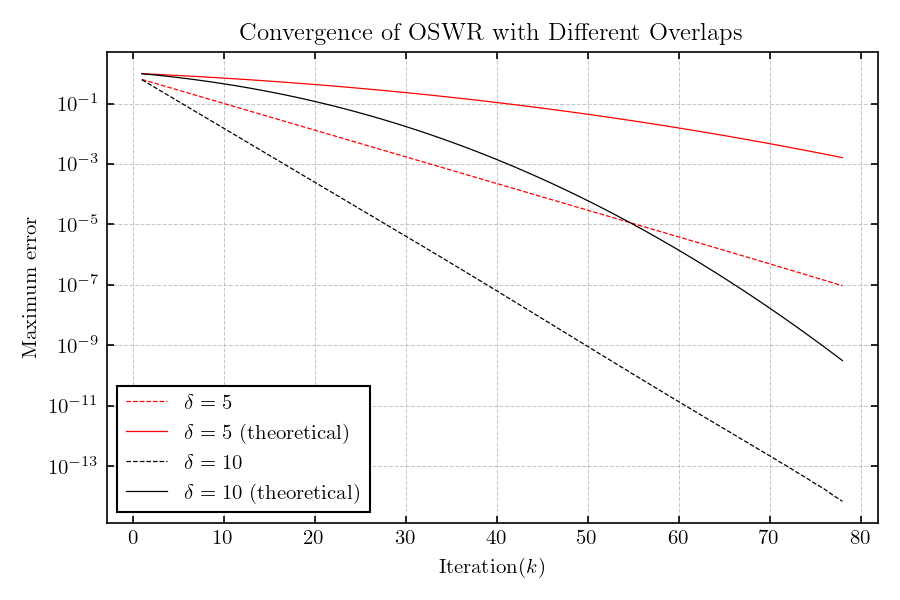

In [18]:
# Visualize the iteration history of the maximum error across subdomains along with the theoretical bounds
visualizer1D_bound = SolutionVisualizer(mesh = femspace1D.mesh, u = oswr_solution1D_10, dt = time_grid[1] - time_grid[0], femspace = femspace1D)

# Determine the number of iterations to visualize based on the shorter history length
niter = min(len(lhs_bound_5), len(lhs_bound_10))

# Define necessary data dictionary for visualization
iter_data = {
    'overlap5': lhs_bound_5[:niter],
    'overlap5(theoretical)': rhs_bound_5[:niter],
    'overlap10': lhs_bound_10[:niter],
    'overlap10(theoretical)': rhs_bound_10[:niter]
}

# Define styles for the plots
styles = {'overlap5': {'label': r'$\delta = 5$', 'color': 'red', 'linestyle': '--', 'linewidth': 0.6},
          'overlap5(theoretical)': {'label': r'$\delta = 5$ (theoretical)', 'color': 'red', 'linestyle': '-', 'linewidth': 0.6},
          'overlap10': {'label': r'$\delta = 10$', 'color': 'black', 'linestyle': '--', 'linewidth': 0.6},
          'overlap10(theoretical)': {'label': r'$\delta = 10$ (theoretical)', 'color': 'black', 'linestyle': '-', 'linewidth': 0.6}}

# Visualize the iteration history of the maximum error across subdomains along with the theoretical bounds
visualizer1D_bound.plot_iteration(data = iter_data, styles = styles, figsize = (6, 4), dpi = 150, 
                            xlabel = r"Iteration($k$)",
                            ylabel = "Maximum error", 
                            title = "Convergence of OSWR with Different Overlaps")

We are done with OSWR method for the 1D heat equation. In the next section, we will introduce the Reduced-Order Overlapping Schwarz Waveform Relaxation (ROSWR) method, which is an extension of the OSWR method that incorporates model order reduction techniques to accelerate the convergence of the Schwarz iterations. The ROSWR method constructs reduced-order models for each subdomain using Proper Orthogonal Decomposition (POD) and uses these reduced-order models to perform the Schwarz iterations more efficiently. We will set up and solve the ROSWR problem for the same 1D heat equation and compare its performance with the standard OSWR method. 

### Reduced-Order Overlapping Schwarz Waveform Relaxation (ROSWR) method

In each iteration of the OSWR method, we need to solve the heat equation on each subdomain, which can be computationally expensive, especially for large-scale problems. The Reduced-Order Overlapping Schwarz Waveform Relaxation (ROSWR) method is an extension of the OSWR method that incorporates model order reduction techniques to accelerate the convergence of the Schwarz iterations. The ROSWR method constructs reduced-order models for each subdomain using Proper Orthogonal Decomposition (POD) and uses these reduced-order models to perform the Schwarz iterations using the method called the **reduced-order compatible lifting approach**. By using reduced-order models, we can significantly reduce the computational cost of each iteration while still capturing the essential dynamics of the solution on each subdomain. In this section, we will set up and solve the ROSWR problem for the same 1D heat equation and compare its performance with the standard OSWR method.

In [ ]:
from rom.roswr_heat import ROSWRProblem

# Define Reduced-Order Schwarz problem with 2 subdomains and overlap of 1 layer of elements with version 2 of the interface boundary decomposition
roswrproblem1D = ROSWRProblem(heat_problem = problem1D, n = 2, overlap = 1, version = 2)

Let us now discuss how we construct local projection matrices for reduced-order models for each subdomain using Proper Orthogonal Decomposition (POD) in the context of the ROSWR method. We first solve the heat problem on the whole domain using the finite element method to obtain a corresponding homogeneous solution, which is then used as a snapshot matrix to construct the local projection matrices for each subdomain. This snapshot matrix is restricted to each subdomain to obtain local snapshot matrices, which are then used to compute the POD modes for each subdomain. The local projection matrices are constructed by taking `r` leading POD modes for each subdomain, where `r` is the desired reduced dimension. These local projection matrices are then used to project the subdomain problems onto a lower-dimensional space, which allows for faster computations during the Schwarz iterations while still capturing the essential dynamics of the solution.

In [ ]:
from rom.pod import POD
from rom.roswr_heat import ROSWRProblem

# Helper function to construct projection matrices for each subdomain by restricting the global snapshot matrix to the subdomain
def proj_matrices(femspace: FEMSpace, roswrproblem: ROSWRProblem, pod: POD) -> dict[int, np.ndarray]:
    projs = {}
    snapshot_matrix = np.zeros((femspace.nnodes, pod.ntime))
    snapshot_matrix[femspace.interior_nodes,:] = pod.compute_snapshots()
    for subdomain_id, subdomain in roswrproblem.subdomains.items():
        subsnap = roswrproblem.restrict(snapshot_matrix, subdomain_id)[subdomain.interior_nodes(),:] # Restrict the snapshot matrix to the subdomain
        V, _, _ = np.linalg.svd(subsnap, full_matrices=False)
        projs[subdomain_id] = V[:, :pod.r]
    return projs

# Compute POD modes for the full-order problem to be used in the Reduced Order Schwarz method
tparams = np.linspace(0, 1, 51)
pod1D = POD(heat_problem = problem1D, time_grid = tparams, lift = 'nodal', theta = 1, r = 10, g = np.vstack([np.zeros(len(tparams)), np.exp(-tparams)]))

# Construct projection matrices for each subdomain for reduced order r = 10
projs1D = proj_matrices(femspace = femspace1D, roswrproblem = roswrproblem1D, pod = pod1D)

Once we have the local projection matrices for each subdomain, we can solve the reduced-order subdomain problems and perform the Schwarz iterations in the reduced space. The `ROSWRProblem` class provides a convenient interface to set up the ROSWR problem. This class takes as input the original heat problem, the number of subdomains, the overlap size, and the version of the interface boundary decomposition to use. The `ROSWRProblem` class then constructs the reduced-order models for each subdomain using the local projection matrices and sets up the Schwarz iterations accordingly. We can then solve the ROSWR problem using its `solve` method, which has similar parameters to the `OSWRProblem` class but also incorporates the reduced-order models into the Schwarz iterations. In `solve` method of the `ROSWRProblem` class, the subdomain problems are solved in the reduced space using the local projection matrices, and the Schwarz iterations are performed by exchanging information at the interfaces in the reduced space. The convergence behavior of the ROSWR method can be analyzed by tracking the history of relevant metrics during the iterations, similar to how we analyzed the OSWR method. By comparing the convergence history and final solution of the ROSWR method with that of the OSWR method, we can assess the effectiveness of model order reduction in accelerating convergence while maintaining accuracy.

In [ ]:
roswr_solution1D = roswrproblem1D.solve(projs = projs1D, time_grid = time_grid, theta = 1, lift = 'nodal', method = 'RAS', maxiter = 50, tol = 1e-6)

In [ ]:
# Visualize the (reconstructed) reduced solution at the mesh vertices
visualizer_roswr = SolutionVisualizer(mesh = femspace1D.mesh, u = roswr_solution1D, dt = time_grid[1] - time_grid[0], femspace = femspace1D)
visualizer_roswr.plot(linewidth = 0.8, linestyle = '-', color = 'red', title = "1D Heat Solution with ROSWR")

Now we visualize the error of the ROSWR solution with respect to the FEM solution using the `SolutionVisualizer` class, similar to how we visualized the error for the OSWR method. The error is computed as the absolute difference between the FEM solution and the ROSWR solution at each vertex and time step, with a small value added to avoid issues with logarithmic scaling when plotting. By visualizing this error, we can gain insights into the accuracy of the ROSWR method and identify regions in space where the error is larger, which may indicate areas where the ROSWR method struggles to capture the solution accurately.

In [ ]:
# Visualize the error between the FEM and ROSWR solutions at the mesh vertices
error1D_roswr = np.abs(heat_solution1D - roswr_solution1D) + 1e-14 # add small value to avoid log(0) issues
visualizer_error = SolutionVisualizer(mesh = femspace1D.mesh, u = error1D_roswr, dt = time_grid[1] - time_grid[0], femspace = femspace1D)
visualizer_error.plot(figsize = (6, 3), dpi = 150, logscale = True, ylabel = 'e', ymin = 1e-14, ymax = 1e-0, linewidth = 0.8, linestyle = '-', color = 'red', title = "Error between FEM and ROSWR Solutions")

It is better to plot both the error of the OSWR solution and the error of the ROSWR solution with respect to the FEM solution to compare their performance.

In [ ]:
error_oswr = {'FEMvsOSWR': error1D_oswr}
styles_error = {'FEMvsOSWR': {'label': 'OSWR', 'color': 'black', 'linestyle': '--', 'linewidth': 0.8}}
visualizer_error.plot(data = error_oswr, styles = styles_error, figsize = (6, 3), dpi = 150, logscale = True, 
                    ymin = 1e-14, ymax = 1e-0, linewidth = 0.8, slabel = "ROSWR", ylabel = 'e',
                    linestyle = '-', color = 'red', title = "OSWR vs ROSWR Error Comparison")

Let us now analyze the convergence behavior of the ROSWR method by tracking the history of relevant metrics during the iterations using a `HistoryConfig` object, similar to how we analyzed the OSWR method. Here, we will only consider the case where we track the global absolute error in the $L^2(0,T;L^2(\Omega))$ norm.

In [ ]:
# Define a history configuration
metrics_roswr = [MetricSpec(MetricType.ABSOLUTE_ERROR, SpatialMode.GLOBAL, TemporalMode.STATIC)]
config_roswr = HistoryConfig(metrics = metrics_roswr, norm = NormType.L2, uh = heat_solution1D, mode = 'fem')

In [ ]:
# Solve the problem using the Reduced-Order Schwarz method with RAS, nodal lifting and theta method with theta = 1 (backward Euler) while tracking the history of the global absolute error in the L2(0,T;L2(Omega)) norm
history1D_roswr, roswr_solution1D = roswrproblem1D.solve(projs = projs1D, time_grid = time_grid, theta = 1, lift = 'nodal', method = 'RAS', maxiter = 100, tol = 1e-9, histconfig = config_roswr)

In [ ]:
# Solution visualization
abs_history_roswr = history1D_roswr.values[MetricType.ABSOLUTE_ERROR]["global"]
visualizer1D = SolutionVisualizer(mesh = femspace1D.mesh, u = roswr_solution1D, dt = time_grid[1] - time_grid[0], femspace = femspace1D)
visualizer1D.plot_iteration(data = abs_history_roswr, figsize = (6, 3), dpi = 150, ylabel = rf"$\| u_{{FEM}} - u_{{ROSWR}} \|_{{L^2(0,{T};L^2({vert1D[0]}, {vert1D[-1]}))}}$", color = 'black', linestyle = '-', linewidth = 0.8)

Let us plot both the convergence history of the OSWR method and the ROSWR method on the same plot to compare their convergence behavior. By plotting the tracked metrics against the iteration number for both methods, we can visually assess how the error evolves across iterations.

In [ ]:
# Solve the problem using the Schwarz method with RAS, nodal lifting and theta method with theta = 1 (backward Euler) while tracking the history of the global absolute error in the L2(0,T;L2(Omega)) norm
history1D_oswr, oswr_solution1D = oswrproblem1D.solve(time_grid = time_grid, theta = 1, lift = 'nodal', method = 'RAS', maxiter = 100, tol = 1e-9, histconfig = config_roswr)
abs_history_oswr = history1D_oswr.values[MetricType.ABSOLUTE_ERROR]["global"]

In [ ]:
# Determine the number of iterations to visualize based on the shorter history length
niter = min(len(abs_history_roswr), len(abs_history_oswr))

# Define necessary data dictionary for visualization
iter_data_compare = {'ROSWR': abs_history_roswr[:niter], 'OSWR': abs_history_oswr[:niter]}

# Define styles for the plots
styles_abs = {'ROSWR': {'label': 'ROSWR', 'color': 'red', 'linestyle': '-', 'linewidth': 0.7},
          'OSWR': {'label': 'OSWR', 'color': 'black', 'linestyle': '-', 'linewidth': 0.7}}

# Visualize the iteration history of the absolute error for both ROSWR and OSWR
visualizer1D_bound.plot_iteration(data = iter_data_compare, styles = styles_abs, figsize = (6, 4), dpi = 150, 
                            xlabel = r"Iteration($k$)", ylabel = 'Absolute Errors', title = "ROSWR vs OSWR Convergence Comparison")

For above experiments we took `r=10` leading POD modes for each subdomain to construct the local projection matrices for the reduced-order models. Let us analyze how the choice of `r` affects the convergence behavior of the ROSWR method by tracking the history of relevant metrics for different values of `r`. By comparing the convergence history for different values of `r`, we can assess the trade-off between computational cost and accuracy in the ROSWR method. Generally, increasing `r` will lead to better accuracy but higher computational cost, while decreasing `r` will reduce computational cost but may lead to a loss of accuracy. By analyzing the convergence history for different values of `r`, we can identify an optimal choice that balances accuracy and efficiency for our specific problem.

In [ ]:
r_values = [5, 10, 15]
r_histories = {}
for r in r_values:
    pod1D = POD(heat_problem = problem1D, time_grid = tparams, lift = 'nodal', theta = 1, r = r, g = np.vstack([np.zeros(len(tparams)), np.exp(-tparams)]))
    projs1D = proj_matrices(femspace = femspace1D, roswrproblem = roswrproblem1D, pod = pod1D)
    history1D_roswr, roswr_solution1D = roswrproblem1D.solve(projs = projs1D, time_grid = time_grid, theta = 1, lift = 'nodal', method = 'RAS', maxiter = 100, tol = 1e-9, histconfig = config_roswr)
    r_histories[r] = history1D_roswr

In [ ]:
history_5 = r_histories[5].values[MetricType.ABSOLUTE_ERROR]["global"]
history_10 = r_histories[10].values[MetricType.ABSOLUTE_ERROR]["global"]
history_15 = r_histories[15].values[MetricType.ABSOLUTE_ERROR]["global"]

# Determine the number of iterations to visualize based on the shorter history length
niter = min(len(history_5), len(history_10), len(history_15))

# Define necessary data dictionary for visualization
r_data = {'5': history_5[:niter], '10': history_10[:niter], '15': history_15[:niter]}

# Define styles for the plots
r_styles = {'5': {'label': r'$r=5$', 'color': 'red', 'linestyle': '-', 'linewidth': 0.7},
            '10': {'label': r'$r=10$', 'color': 'black', 'linestyle': '-', 'linewidth': 0.7},
            '15': {'label': r'$r=15$', 'color': 'blue', 'linestyle': '-', 'linewidth': 0.7}}


# Visualize the iteration history of the absolute error for different reduced order values in ROSWR
visualizer1D_bound.plot_iteration(data = r_data, styles = r_styles, figsize = (6, 4), dpi = 150, 
                            xlabel = r"Iteration($k$)", ylabel = 'Absolute Errors', title = "")